In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv ("E:\Pyhton code\Machine Learning\house_data.csv")
print(df.head())

   size  price
0   500    150
1   800    220
2  1000    300
3  1200    340
4  1500    400


In [4]:
x = df['size'].values
y = df['price'].values

print(x.shape)
print(y.shape)

(10,)
(10,)


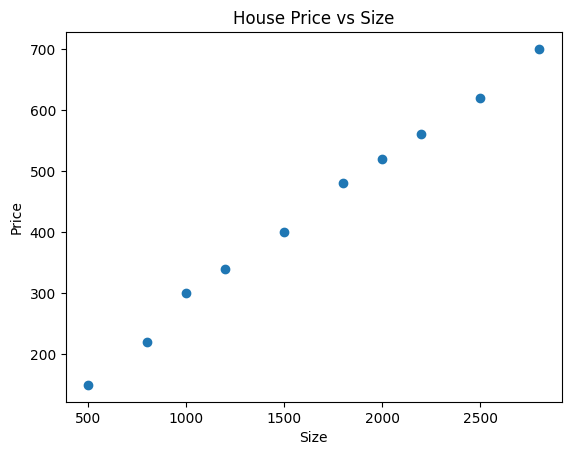

In [5]:
plt.scatter(x,y)
plt.xlabel("Size")
plt.ylabel('Price')
plt.title("House Price vs Size")
plt.show()

In [ ]:
w = 0
b = 0

def predict(x,w,b):
    return w * x + b #linear regression equation, to predict y using x.

In [ ]:
def cost_function (x,y,w,b): 
    m = len(x) #number of training examples
    
    predictions = predict(x,w,b) #predicted values of y using the current parameters w and b.
    error = predictions - y #difference between predicted values and actual values of y.
    
    cost = (1/(2*m)) * np.sum(error**2) #mean squared error cost function, which measures the average
                                        #squared difference between predicted values and actual values of y.
                                        
    return cost #returns the cost, which is a measure of how well the model is performing 
                # with the current parameters w and b.

In [ ]:
# Compute gradient is a function that calculates the gradients of the cost function with respect to 
# the parameters w and b, which are used to update the parameters during the gradient descent optimization process.
def compute_gradient(x,y,w,b):
    m = len(x) #number of training examples
    
    predictions = predict(x,w,b) #predicted values of y using the current parameters w and b.
    error = predictions - y #difference between predicted values and actual values of y.
    
    dj_dw = (1/m)  * np.sum(error*x) #gradient of the cost function with respect to w, which measures 
                                     # how much the cost function changes with a small change in w.
                                     
    dj_db = (1/m) * np.sum(error) #gradient of the cost function with respect to b, which measures how
                                  # much the cost function changes with a small change in b.
    
    return dj_dw, dj_db #returns the gradients dj_dw and dj_db, which are used to update the parameters 
                        # w and b during the gradient descent optimization process.

In [ ]:
# Gradient descent is an optimization algorithm used to minimize the cost function by iteratively 
# updating the parameters w and b in the direction of the negative gradient.

def gradient_descent(x,y,w,b,alpha,iterations):
    cost_history = [] #list to store the cost at each iteration of gradient descent, which can be used to 
                      # visualize the convergence of the algorithm.
    
    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(x,y,w,b) #compute the gradients of the cost function with respect to
                                                 # w and b using the compute_gradient function.
        
        w = w - alpha * dj_dw #update the parameter w by subtracting the product of the learning rate alpha 
                              # and the gradient dj_dw from the current value of w.
                              
        b = b - alpha * dj_db #update the parameter b by subtracting the product of the learning rate alpha and
                              # the gradient dj_db from the current value of b.
        
        cost_history.append(compute_gradient(x,y,w,b)) #compute the cost using the updated parameters w and b, 
                # and append it to the cost_history list to track the cost at each iteration of gradient descent.
                
    return w,b,cost_history #returns the final values of w and b after performing gradient descent, as well as 
                            # the cost history for visualization.
        

In [ ]:
alpha = 0.00000001 #learning rate, which determines the step size at each iteration of gradient descent. 
# A smaller learning rate may lead to slower convergence, while a larger learning rate may cause overshooting and divergence.

iterations = 1000 #number of iterations for gradient descent, which determines how many times the parameters w and b
# will be updated based on the computed gradients. More iterations may lead to better convergence, but it may also increase the computational time.

w,b,cost_history = gradient_descent(x,y,w,b,alpha,iterations) #performs gradient descent to optimize the parameters w 
                      # and b, and returns the final values of w and b, as well as the cost history for visualization.

print("w:",w)
print("b:",b)


w: 0.25842509012028525
b: 0.00021034079690475247


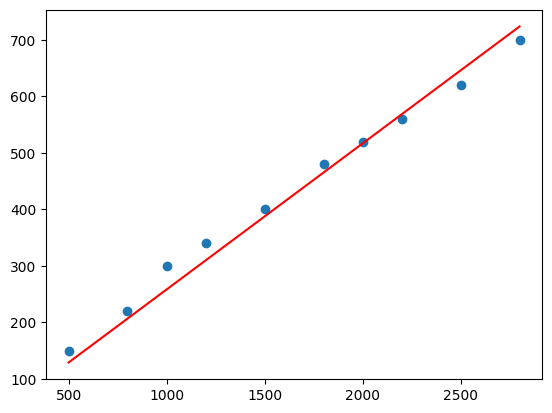

In [ ]:
plt.scatter(x,y) #
plt.plot(x,predict(x,w,b), color='red') #plots the original data points (x,y) as a scatter plot and the predicted
# line using the optimized parameters w and b as a red line on the same graph to visualize the fit of the linear regression model to the data.
plt.xlabel("Size")
plt.ylabel('Price')
plt.title("House Price vs Size with Linear Regression Fit")
plt.show()

In [ ]:
def r2_score(y,y_pred):
    ss_total = np.sum((y - np.mean(y))**2) #total sum of squares, which measures the total variability in the actual
                                           # values of y.
                                           
    ss_residual = np.sum((y - y_pred)**2) #residual sum of squares, which measures the variability in the actual 
                                          # values of y that is not explained by the predicted values y_pred.
    
    r2 = 1 - (ss_residual/ss_total) #R-squared score, which is a measure of how well the predicted values y_pred
      # explain the variability in the actual values of y. It ranges from 0 to 1, where a higher R-squared score
      # indicates a better fit of the model to the data.
      
    return r2 #returns the R-squared score, which can be used to evaluate the performance of the linear    
              # regression model.

In [ ]:
y_pred = predict(x,w,b) #predicted values of y using the optimized parameters w and b, which can be used to evaluate
                        # the performance of the linear regression model.
r2 = r2_score(y,y_pred) #calculates the R-squared score using the actual values of y and the predicted values y_pred,
                        # which can be used to evaluate the performance of the linear regression model.
print("R2 Score:", r2)

R2 Score: 0.9827258690422596


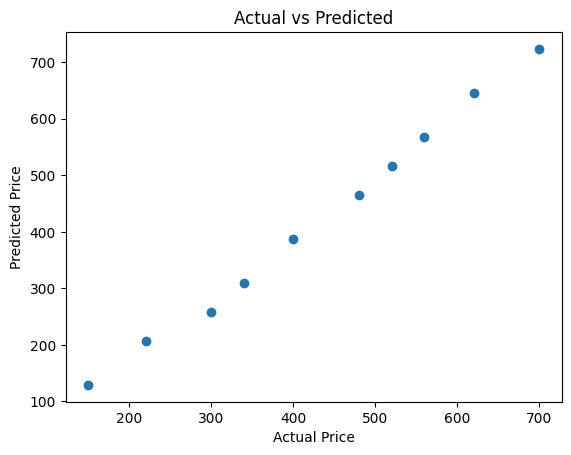

In [ ]:
plt.scatter(y,y_pred) #plots a scatter plot of the actual values of y on the x-axis and the predicted values y_pred on
# the y-axis to visualize the relationship between the actual and predicted values. Ideally, if the model is performing
# well, the points should be close to a straight line with a slope of 1, indicating that the predicted values are 
# close to the actual values.
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split 

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state = 42)
#Splits the dataset into training and testing sets, where x_train and y_train are used to train the linear regression
# model, and x_test and y_test are used to evaluate the performance of the model on unseen data. The test_size parameter specifies the proportion of the dataset to be included in the test set, and random_state is used to ensure reproducibility of the split.


In [ ]:
w,b,J_history = gradient_descent(x_train,y_train,w,b,alpha,iterations)
#Trains the linear regression model using the training data (x_train and y_train) by performing gradient descent
# optimization to find the optimal parameters w and b. The cost history J_history is also returned for visualization of the convergence of the algorithm.


In [ ]:
y_pred_test = predict(x_test, w, b)
#Predicts the values of y for the test set (x_test) using the optimized parameters w and b obtained from training the
#model on the training set. The predicted values y_pred_test can be used to evaluate the performance of the model on unseen data.


In [ ]:
r2_test = r2_score(y_test, y_pred_test) #calculates the R-squared score for the test set using the actual values of y_test and the predicted values y_pred_test, which can be used to evaluate the performance of the linear regression model on unseen data.
print("Test R2 ScoreL",r2_test)

Test R2 ScoreL 0.9859042344680243
